# TSLA — Modeling and Analysis

This notebook covers EDA and walk-forward model training/evaluation for **TSLA** (Tesla, Inc.).

**Data source:** `data/TSLA_features.csv` (Yahoo Finance, 2015–2025, ~2,515 rows)

**Models:**
- Regression: Linear Regression, Ridge Regression, XGBoost
- Classification: Logistic Regression, Random Forest

**Walk-forward validation:** 63-day training window, 42-day test window (~57 folds)

> **Note:** VIX time series and SPY vs TSLA correlation charts are in `spy_modeling.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from xgboost import XGBRegressor

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────
tsla_raw = pd.read_csv("data/TSLA_features.csv", parse_dates=["date"], index_col="date")

print(f"TSLA: {len(tsla_raw):,} rows | {tsla_raw.index[0].date()} \u2192 {tsla_raw.index[-1].date()}")
print(f"Columns ({len(tsla_raw.columns)}): {list(tsla_raw.columns)}")

TSLA: 2,515 rows | 2015-01-02 → 2024-12-30
Columns (35): ['adj_close', 'close', 'high', 'low', 'open', 'volume', 'daily_return', 'weekly_return', 'ma_7', 'ma_21', 'ma_cross', 'dist_from_ma21', 'daily_range', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20', 'volume_change', 'volume_ma20', 'volume_ratio', 'lag_return_1', 'lag_return_3', 'lag_return_5', 'month', 'quarter', 'season_num', 'season', 'is_earnings_week', 'vix', 'is_major_event', 'target_direction', 'target_return']


In [3]:
# ── Feature set ───────────────────────────────────────────────────────────
FEATURES = [
    # Price momentum
    "daily_return",    # today's % price change
    "weekly_return",   # 5-day % price change
    "lag_return_1",    # yesterday's return
    "lag_return_3",    # 3-day lagged return
    "lag_return_5",    # 5-day lagged return
    # Trend
    "dist_from_ma21",  # distance from 21-day moving average
    "ma_cross",        # 7-day MA > 21-day MA crossover signal
    # MACD
    "macd_hist",       # MACD histogram (crossover signal; macd/macd_signal removed — redundant)
    # Volatility
    "daily_range",     # intraday high-low spread / close
    "volatility_20",   # 20-day rolling std (volatility_7 removed — redundant with daily_range)
    "bb_position",     # Bollinger Band position
    # Volume
    "volume_change",   # day-over-day volume % change
    "volume_ratio",    # volume / 20-day average volume
    # Momentum oscillator
    "rsi_14",          # 14-day RSI
    # Event flags
    "is_major_event",  # VIX > 30
    "is_earnings_week",# earnings calendar flag
]

TRAIN_WINDOW = 63   # ~3 months
TEST_WINDOW  = 42   # ~2 months


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + test_window <= n:
        train_idx = list(range(start, start + train_window))
        test_idx  = list(range(start + train_window, start + train_window + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y = df[target_col].values

    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler

In [4]:
def run_linear_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LINEAR REGRESSION — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, last_model = [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)), "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Feature coefficients (last fold):")
    coef_df = pd.DataFrame({"feature": FEATURES, "coefficient": last_model.coef_}).sort_values("coefficient", key=abs, ascending=False)
    print(coef_df.to_string(index=False))
    return last_model, metrics_df, preds_df


def run_logistic_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LOGISTIC REGRESSION — Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, agg_cm, last_model = [], [], np.zeros((3, 3), dtype=int), None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        model = LogisticRegression(max_iter=1000, C=0.1)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold": fold, "accuracy": accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall": report["macro avg"]["recall"],
                              "f1": report["macro avg"]["f1-score"]})
        cm = confusion_matrix(y_test, preds, labels=[-1, 0, 1])
        agg_cm += cm
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  ± {metrics_df[col].std():>7.4f}")
    print("\n  Aggregate confusion matrix (all folds):")
    labels = ["Down", "Flat", "Up"]
    print(pd.DataFrame(agg_cm, index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels]).to_string())
    print("\n  Feature log-odds (last fold):")
    coef_df = pd.DataFrame({"feature": FEATURES, "log_odds": last_model.coef_[0]}).sort_values("log_odds", key=abs, ascending=False)
    print(coef_df.to_string(index=False))
    return last_model, metrics_df, preds_df


def run_ridge_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RIDGE REGRESSION — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, last_model = [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)), "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Feature coefficients (last fold):")
    coef_df = pd.DataFrame({"feature": FEATURES, "coefficient": last_model.coef_}).sort_values("coefficient", key=abs, ascending=False)
    print(coef_df.to_string(index=False))
    return last_model, metrics_df, preds_df


def run_xgboost(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("XGBOOST — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, last_model = [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fold_metrics.append({"fold": fold, "mae": mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)), "r2": r2_score(y_test, preds)})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))
    return last_model, metrics_df, preds_df


def run_random_forest(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RANDOM FOREST — Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, agg_cm, last_model = [], [], np.zeros((3, 3), dtype=int), None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold": fold, "accuracy": accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall": report["macro avg"]["recall"],
                              "f1": report["macro avg"]["f1-score"]})
        cm = confusion_matrix(y_test, preds, labels=[-1, 0, 1])
        agg_cm += cm
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  ± {metrics_df[col].std():>7.4f}")
    print("\n  Aggregate confusion matrix (all folds):")
    labels = ["Down", "Flat", "Up"]
    print(pd.DataFrame(agg_cm, index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels]).to_string())
    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))
    return last_model, metrics_df, preds_df

In [5]:
SEASON_MAP = {
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",  10: "Fall",  11: "Fall",
    12: "Winter", 1: "Winter", 2: "Winter"
}


def seasonal_summary(preds_df, task, label=""):
    df = preds_df.copy()
    df["season"] = pd.to_datetime(df["date"]).dt.month.map(SEASON_MAP)
    header = f"SEASONAL BREAKDOWN \u2014 {label}" if label else "SEASONAL BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)
    season_order = ["Spring", "Summer", "Fall", "Winter"]
    rows = []
    if task == "regression":
        for season in season_order:
            s = df[df["season"] == season]
            if len(s) < 2: continue
            rows.append({"season": season, "n": len(s),
                         "rmse": round(np.sqrt(mean_squared_error(s["actual"], s["predicted"])), 6),
                         "mae":  round(mean_absolute_error(s["actual"], s["predicted"]), 6),
                         "r2":   round(r2_score(s["actual"], s["predicted"]), 4)})
    elif task == "classification":
        for season in season_order:
            s = df[df["season"] == season]
            if len(s) < 2: continue
            report = classification_report(s["actual"], s["predicted"], output_dict=True, zero_division=0)
            rows.append({"season": season, "n": len(s),
                         "f1":        round(report["macro avg"]["f1-score"], 4),
                         "precision": round(report["macro avg"]["precision"], 4),
                         "recall":    round(report["macro avg"]["recall"], 4),
                         "accuracy":  round(accuracy_score(s["actual"], s["predicted"]), 4)})
    print(pd.DataFrame(rows).to_string(index=False))
    return pd.DataFrame(rows)

## Exploratory Data Analysis — TSLA (2015–2025)

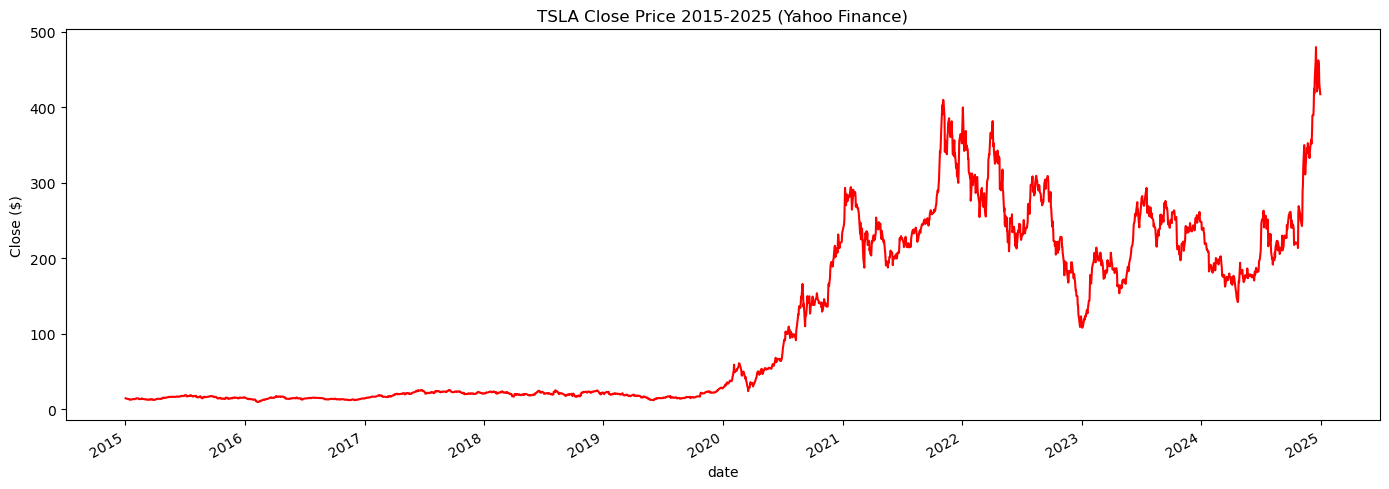

          open     high      low    close        volume
count  2515.00  2515.00  2515.00  2515.00  2.515000e+03
mean    115.58   118.13   112.87   115.56  1.123272e+08
std     114.17   116.75   111.36   114.10  7.408223e+07
min       9.49    10.33     9.40     9.58  1.062000e+07
25%      17.17    17.48    16.89    17.19  6.681690e+07
50%      28.30    28.71    27.33    28.50  9.286200e+07
75%     220.83   225.25   215.29   220.18  1.298032e+08
max     475.90   488.54   457.51   479.86  9.140820e+08


In [6]:
# TSLA CLOSE PRICE
fig, ax = plt.subplots(figsize=(14, 5))
tsla_raw["close"].plot(ax=ax, color="red", title="TSLA Close Price 2015-2025 (Yahoo Finance)")
ax.set_ylabel("Close ($)")
plt.tight_layout()
plt.savefig("img/tsla_close_price.png", dpi=150, bbox_inches="tight")
plt.show()
print(tsla_raw[["open","high","low","close","volume"]].describe().round(2))

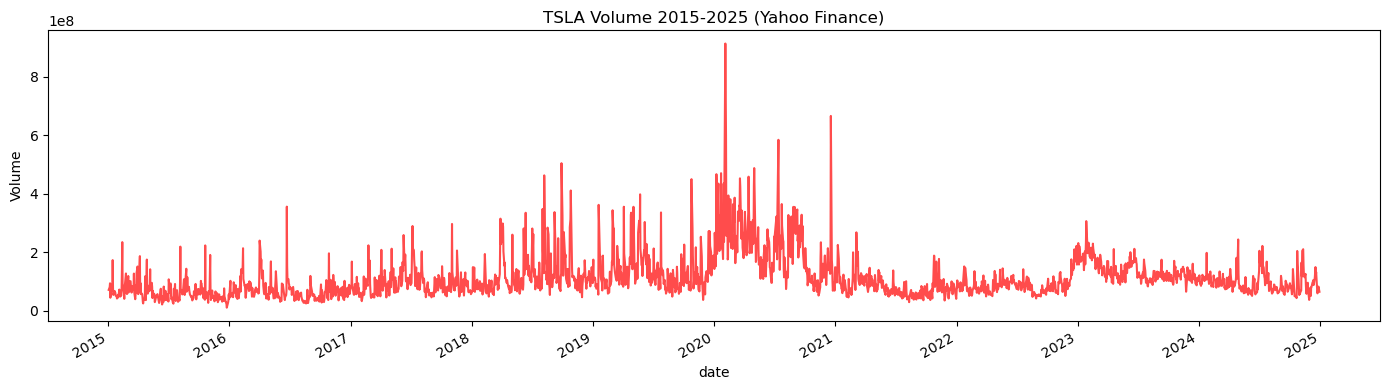

In [7]:
# TSLA VOLUME
fig, ax = plt.subplots(figsize=(14, 4))
tsla_raw["volume"].plot(ax=ax, color="red", alpha=0.7, title="TSLA Volume 2015-2025 (Yahoo Finance)")
ax.set_ylabel("Volume")
plt.tight_layout()
plt.savefig("img/tsla_volume.png", dpi=150, bbox_inches="tight")
plt.show()

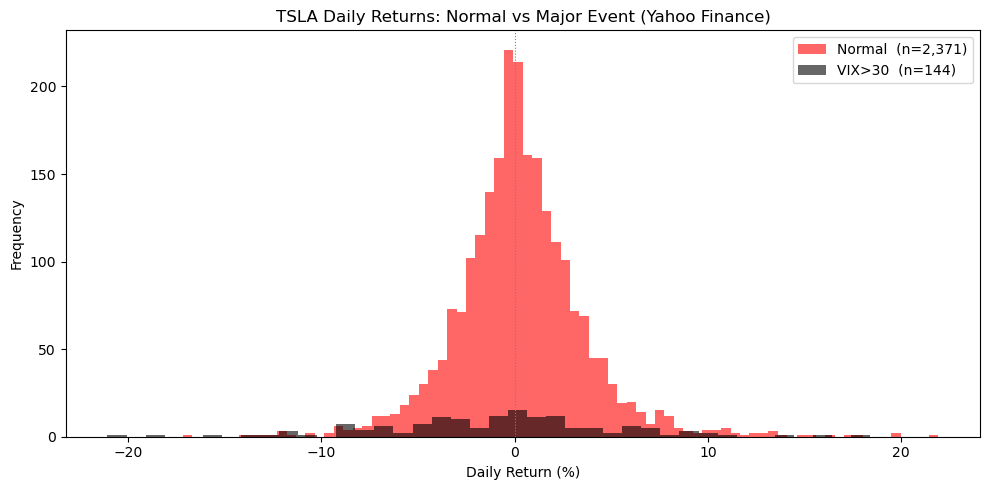

Normal days:  mean=0.2617%  std=3.3728%
Event days:   mean=-0.8628%  std=6.1764%


In [8]:
# VIX vs DAILY RETURNS — normal vs stress periods (TSLA)
normal = tsla_raw[tsla_raw["is_major_event"] == 0]["daily_return"].dropna() * 100
event  = tsla_raw[tsla_raw["is_major_event"] == 1]["daily_return"].dropna() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normal, bins=80, alpha=0.6, color="red",   label=f"Normal  (n={len(normal):,})")
ax.hist(event,  bins=40, alpha=0.6, color="black", label=f"VIX>30  (n={len(event):,})")
ax.axvline(x=0, color="gray", linewidth=0.8, linestyle=":")
ax.set_title("TSLA Daily Returns: Normal vs Major Event (Yahoo Finance)")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("img/tsla_vix_vs_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Normal days:  mean={normal.mean():.4f}%  std={normal.std():.4f}%")
print(f"Event days:   mean={event.mean():.4f}%  std={event.std():.4f}%")

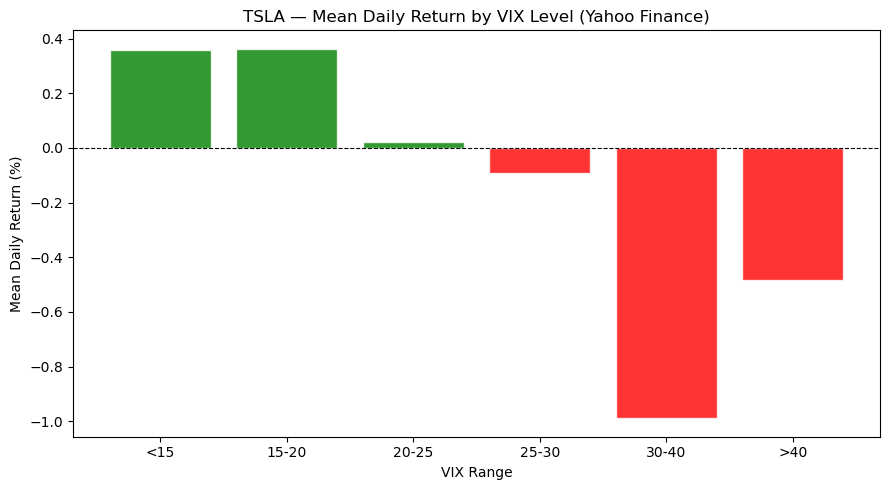

In [9]:
# VIX LEVEL vs MEAN DAILY RETURN (binned) — TSLA
tsla_eda = tsla_raw.copy()
tsla_eda["vix_bin"] = pd.cut(tsla_eda["vix"], bins=[0, 15, 20, 25, 30, 40, 100],
                              labels=["<15","15-20","20-25","25-30","30-40",">40"])
binned = tsla_eda.groupby("vix_bin", observed=True)["daily_return"].mean() * 100
bar_colors = ["green" if v >= 0 else "red" for v in binned.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(binned.index, binned.values, color=bar_colors, alpha=0.8, edgecolor="white")
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("TSLA \u2014 Mean Daily Return by VIX Level (Yahoo Finance)")
ax.set_xlabel("VIX Range")
ax.set_ylabel("Mean Daily Return (%)")
plt.tight_layout()
plt.savefig("img/tsla_vix_binned_returns.png", dpi=150, bbox_inches="tight")
plt.show()

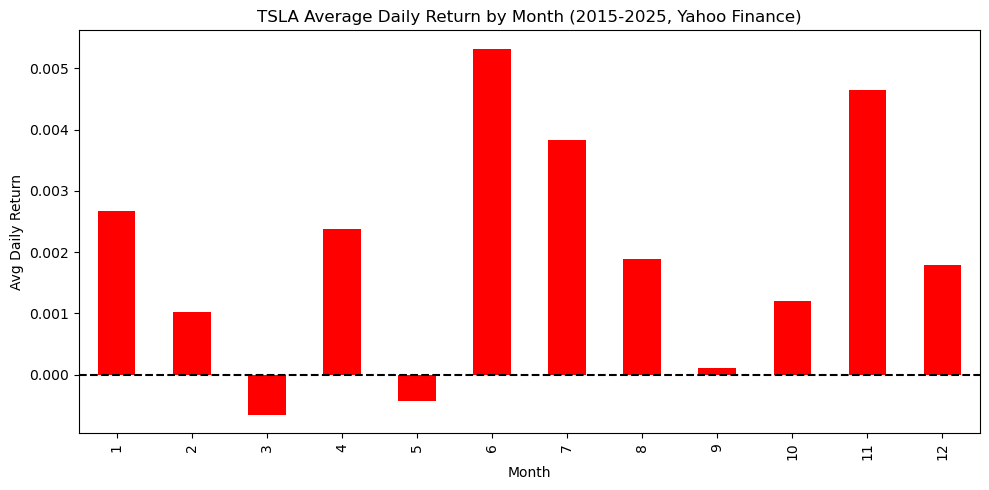

In [10]:
# AVERAGE DAILY RETURN BY MONTH — TSLA
tsla_eda["month"] = tsla_eda.index.month

fig, ax = plt.subplots(figsize=(10, 5))
tsla_eda.groupby("month")["daily_return"].mean().plot(
    kind="bar", ax=ax, color="red",
    title="TSLA Average Daily Return by Month (2015-2025, Yahoo Finance)")
ax.axhline(y=0, color="black", linestyle="--")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Daily Return")
plt.tight_layout()
plt.savefig("img/tsla_monthly_returns.png", dpi=150, bbox_inches="tight")
plt.show()

## TSLA — Model Training and Evaluation

In [11]:
# ── Softened direction target (5b) ───────────────────────────────────────
# TSLA threshold: 1.5% — ~3x SPY volatility; smaller moves classified as FLAT (0)
def soften_direction(pct_change, threshold):
    if pct_change > threshold:
        return 1    # UP
    elif pct_change < -threshold:
        return -1   # DOWN
    else:
        return 0    # FLAT

tsla_raw["target_direction"] = (
    tsla_raw["close"].pct_change(1).shift(-1)
    .apply(lambda x: soften_direction(x, threshold=0.015))
)

# ── Forward realized volatility target (5c) ───────────────────────────────
# std of the next 5 daily returns — features are better aligned to volatility than to return direction
tsla_raw["target_volatility"] = (
    tsla_raw["close"].pct_change()
    .shift(-1)
    .rolling(5)
    .std()
    .shift(-4)
)

# ── Prepare TSLA modeling data ────────────────────────────────────────────
required_cols = FEATURES + ["target_direction", "target_volatility"]
tesla_df = tsla_raw.dropna(subset=required_cols).copy()

print(f"Rows after dropping NaN: {len(tesla_df):,}")
print(f"Date range: {tesla_df.index.min().date()} \u2192 {tesla_df.index.max().date()}")
print(f"Major event days (VIX > 30): {tesla_df['is_major_event'].sum()}")
print(f"Earnings weeks:              {tesla_df['is_earnings_week'].sum()}")
print(f"Walk-forward folds:          {len(walk_forward_splits(tesla_df))}")
print(f"\ntarget_direction distribution:")
print(tesla_df["target_direction"].value_counts().sort_index().rename({-1: "Down (-1)", 0: "Flat (0)", 1: "Up (1)"}))

# ── Regression models ─────────────────────────────────────────────────────
lin_model,   lin_metrics,   lin_preds   = run_linear_regression(tesla_df)
seasonal_summary(lin_preds, "regression", "Linear Regression \u2014 TSLA")

ridge_model, ridge_metrics, ridge_preds = run_ridge_regression(tesla_df)
seasonal_summary(ridge_preds, "regression", "Ridge Regression \u2014 TSLA")

xgb_model,   xgb_metrics,   xgb_preds   = run_xgboost(tesla_df)
seasonal_summary(xgb_preds, "regression", "XGBoost \u2014 TSLA")

# ── Classification models ─────────────────────────────────────────────────
log_model, log_metrics, log_preds = run_logistic_regression(tesla_df)
seasonal_summary(log_preds, "classification", "Logistic Regression \u2014 TSLA")

rf_model,  rf_metrics,  rf_preds  = run_random_forest(tesla_df)
seasonal_summary(rf_preds, "classification", "Random Forest \u2014 TSLA")

Rows after dropping NaN: 2,510
Date range: 2015-01-02 → 2024-12-20
Major event days (VIX > 30): 144
Earnings weeks:              420
Walk-forward folds:          58

target_direction distribution:
target_direction
Down (-1)     651
Flat (0)     1100
Up (1)        759
Name: count, dtype: int64

LINEAR REGRESSION — 5-day forward volatility
Walk-forward: 58 folds  (train=63d, test=42d)



  Metric          Mean         Std
  --------------------------------
  RMSE        0.030008  ±  0.022531
  MAE         0.024770  ±  0.019399
  R²         -6.270689  ± 10.978247

  Feature coefficients (last fold):
         feature  coefficient
  dist_from_ma21     0.060470
       macd_hist    -0.024562
          rsi_14    -0.024229
     bb_position    -0.009575
        ma_cross    -0.007250
   volatility_20    -0.006642
    volume_ratio    -0.005404
is_earnings_week     0.004482
   volume_change     0.003998
    daily_return    -0.003037
    lag_return_3     0.001827
    lag_return_1    -0.001099
   weekly_return    -0.000936
     daily_range    -0.000545
  is_major_event    -0.000302
    lag_return_5     0.000226

SEASONAL BREAKDOWN — Linear Regression — TSLA
season   n     rmse      mae      r2
Spring 614 0.044576 0.027556 -4.2929
Summer 645 0.034284 0.023363 -3.8344
  Fall 630 0.031809 0.023629 -1.6322
Winter 547 0.038081 0.024617 -2.8449

RIDGE REGRESSION — 5-day forward volatili


  Metric          Mean         Std
  --------------------------------
  RMSE        0.019440  ±  0.011024
  MAE         0.015565  ±  0.009102
  R²         -1.324008  ±  1.571771

  Feature importances (last fold):
         feature  importance
is_earnings_week    0.355891
  dist_from_ma21    0.119950
     bb_position    0.101138
        ma_cross    0.083904
       macd_hist    0.071051
   volatility_20    0.068874
    lag_return_1    0.040993
    lag_return_5    0.039306
    volume_ratio    0.034045
    daily_return    0.026004
          rsi_14    0.017629
   weekly_return    0.015267
    lag_return_3    0.009362
     daily_range    0.009199
   volume_change    0.007388
  is_major_event    0.000000

SEASONAL BREAKDOWN — XGBoost — TSLA
season   n     rmse      mae      r2
Spring 614 0.024517 0.016258 -0.6010
Summer 645 0.017845 0.014056 -0.3097
  Fall 630 0.023631 0.016905 -0.4527
Winter 547 0.022837 0.015022 -0.3828

LOGISTIC REGRESSION — Predicting price direction
Walk-forward: 58 fol


  Metric            Mean       Std
  --------------------------------
  F1              0.2951  ±  0.0692
  Precision       0.3337  ±  0.1114
  Recall          0.3521  ±  0.0564
  Accuracy        0.3941  ±  0.1047

  Aggregate confusion matrix (all folds):
             Pred Down  Pred Flat  Pred Up
Actual Down        117        347      166
Actual Flat        198        651      219
Actual Up          139        407      192

  Feature log-odds (last fold):
         feature  log_odds
    lag_return_3 -0.175531
   volume_change  0.170575
          rsi_14  0.164467
    daily_return  0.141278
     bb_position -0.108799
    lag_return_1 -0.108796
   volatility_20 -0.100277
is_earnings_week  0.078688
  is_major_event -0.077128
       macd_hist -0.076785
    volume_ratio -0.066369
   weekly_return  0.056770
    lag_return_5 -0.050784
  dist_from_ma21  0.050466
        ma_cross  0.016544
     daily_range  0.010117

SEASONAL BREAKDOWN — Logistic Regression — TSLA
season   n     f1  precision 


  Metric            Mean       Std
  --------------------------------
  F1              0.2946  ±  0.0824
  Precision       0.3300  ±  0.1191
  Recall          0.3326  ±  0.0752
  Accuracy        0.3810  ±  0.1122

  Aggregate confusion matrix (all folds):
             Pred Down  Pred Flat  Pred Up
Actual Down        137        298      195
Actual Flat        221        585      262
Actual Up          182        350      206

  Feature importances (last fold):
         feature  importance
    daily_return    0.090017
    lag_return_3    0.089716
   weekly_return    0.086338
    lag_return_1    0.081939
    volume_ratio    0.077781
     bb_position    0.077190
     daily_range    0.076011
    lag_return_5    0.071258
   volume_change    0.070453
          rsi_14    0.059089
   volatility_20    0.058008
  dist_from_ma21    0.054557
       macd_hist    0.053632
        ma_cross    0.045131
is_earnings_week    0.004639
  is_major_event    0.004239

SEASONAL BREAKDOWN — Random Forest — TSL

,season,n,f1,precision,recall,accuracy
0,Spring,614,0.3432,0.3456,0.3461,0.3648
1,Summer,645,0.3554,0.3570,0.3566,0.3953
2,Fall,630,0.3488,0.3492,0.3573,0.3968
3,Winter,547,0.3247,0.3251,0.3294,0.3638
